In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def ExpA_diag(h,M):
  '''essa calculadora de exponencial de matriz só é válida para matriz diagonal
  sendo M --- a matriz que queremos encontrar a exponencial'''
  DIAG = np.zeros(len(M))
  for i in range(len(M)):
    DIAG[i] = np.diag(M)[i]
  EA = np.diag(np.exp(h*DIAG))
  return EA

def phi_1_ajustado1(h,M):
  if M == [[0]] or h == 0:
    phi = np.array([np.eye(len(M))])
  elif h <=10**(-8):
    phi = np.array([np.eye(len(M)) + 0.5*h*M])
  else:
    phi = np.dot(ExpA_diag(h,M)-np.eye(len(M)),np.linalg.inv(h*M))
  return phi



def phi_1_inicial(h,M):
  phi = np.dot(ExpA_diag(h,M)-np.eye(len(M)),np.linalg.inv(h*M))
  return phi

##--Teste convergência do phi_1 para passos pequenos

/tmp/ipykernel_2967/137096126.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  var_phi_ajustado1[i] = phi_1_ajustado1(var_h[i],A)


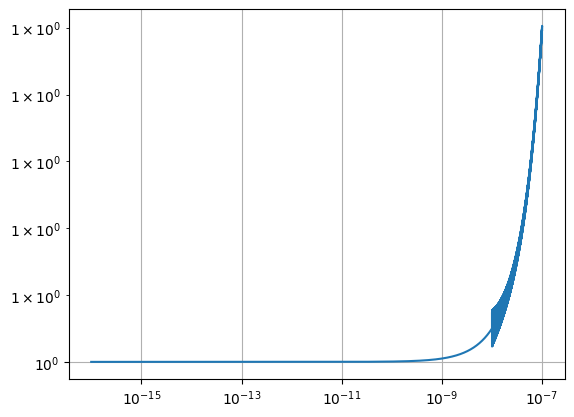

In [ ]:
A = np.array([[2]])
M = 100000
var_h = np.linspace(10**(-16),10**(-7),M)
var_phi_ajustado1 = np.zeros_like(var_h)
for i in range (M):
  var_phi_ajustado1[i] = phi_1_ajustado1(var_h[i],A)

plt.xscale('log')
plt.yscale('log')
plt.grid()

plt.plot(var_h,var_phi_ajustado1)
plt.show()


In [ ]:
A = np.array([[2]])
M = 100000
var_h = np.linspace(10**(-16),10**(-7),M)
var_phi_inicial = np.zeros_like(var_h)
for i in range (M):
  var_phi_inicial[i] = phi_1_inicial(var_h[i],A)


/tmp/ipykernel_2967/1553900953.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  var_phi_inicial[i] = phi_1_inicial(var_h[i],A)


<>:4: SyntaxWarning: invalid escape sequence '\D'
<>:4: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_2967/3351388634.py:4: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel('$\Delta$ t')


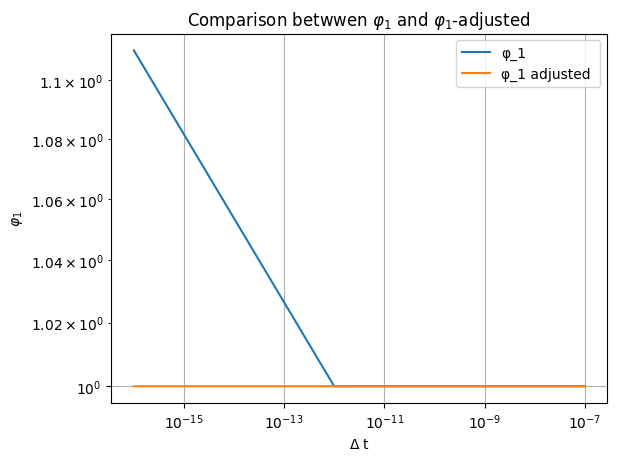

In [ ]:
plt.plot(var_h,var_phi_inicial,label='φ_1')
plt.plot(var_h,var_phi_ajustado1, label = 'φ_1 adjusted ')
plt.legend()
plt.xlabel('$\Delta$ t')
plt.ylabel('$φ_1$')
plt.title('Comparison betwwen $φ_1$ and $φ_1$-adjusted ')
plt.xscale('log')
plt.yscale('log')
plt.grid()

In [ ]:
def phi_2_ajustado(h,M):
  if M == [[0]] or h == 0:
    phi = np.array([0.5*np.eye(len(M))])
  elif h <=10**(-5):
    phi = np.array([0.5*np.eye(len(M)) + (1/6)*h*M])
  else:
    phi = np.dot((ExpA_diag(h,M) - (h*M) - np.eye(len(M))),np.linalg.inv((h**2)*np.dot(M,M)))
  return phi

def phi_2_inicial(h,M):
  phi = np.dot((ExpA_diag(h,M) - (h*M) - np.eye(len(M))),np.linalg.inv((h**2)*np.dot(M,M)))
  return phi

In [ ]:
A = np.array([[2]])
M = 1000000
var_h = np.linspace(-10**(-4),10**(-4),M)
var_phi1 = np.zeros_like(var_h)
var_phi2 = np.zeros_like(var_h)
for i in range (M):
  var_phi1[i] = phi_2_ajustado(var_h[i],A)
  var_phi2[i] = phi_2_inicial(var_h[i],A)

/tmp/ipykernel_2967/723108533.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  var_phi1[i] = phi_2_ajustado(var_h[i],A)
/tmp/ipykernel_2967/723108533.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  var_phi2[i] = phi_2_inicial(var_h[i],A)


<>:10: SyntaxWarning: invalid escape sequence '\D'
<>:10: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_2967/3616103173.py:10: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel('$\Delta $ t')


Text(0, 0.5, '$φ_2$')

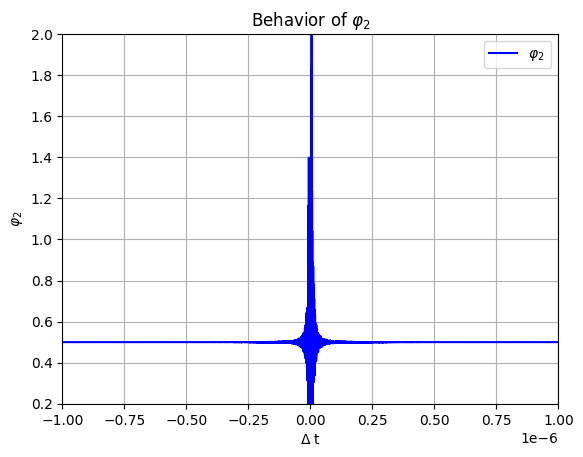

In [ ]:

plt.grid()

plt.title('Behavior of $φ_2$')
plt.plot(var_h,var_phi2,color = 'b',label = '$φ_2$ ')


plt.ylim(0.2,2)
plt.xlim(-10**-6,10**-6)
plt.legend()
plt.xlabel('$\Delta $ t')
plt.ylabel('$φ_2$')

<>:12: SyntaxWarning: invalid escape sequence '\D'
<>:12: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_2967/2889059393.py:12: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel('$\Delta $ t')
/tmp/ipykernel_2967/2889059393.py:10: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(-10**-6,10**-6)


Text(0, 0.5, '$φ_2$')

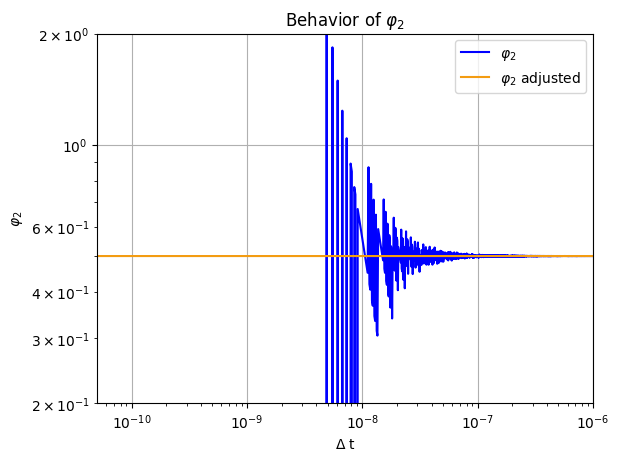

In [ ]:
plt.xscale('log')
plt.yscale('log')
plt.grid()

plt.title('Behavior of $φ_2$')
plt.plot(var_h,var_phi2,color = 'b',label = '$φ_2$ ')
plt.plot(var_h,var_phi1,color = '#F39C12',label = '$φ_2$ adjusted')

plt.ylim(0.2,2)
plt.xlim(-10**-6,10**-6)
plt.legend()
plt.xlabel('$\Delta $ t')
plt.ylabel('$φ_2$')